# Quantum Counting

In [43]:
import qiskit
from qiskit import *
import qiskit_ibm_runtime
import qiskit_aer

In [44]:
# solution set lives in V^n 
n = 3
T = {2, 4, 6}

# ancilla qubits for phase estimation
t = 3

In [45]:
def subU_f(qc, q, a : int):
    # implement the oracle for a single element a of T
    
    # convert to binary with 3 bits, reverse endianness
    e = f"{a:03b}"[::-1]
    print(e)
    
    for i, bit in enumerate(e):
        if bit == '0':
            qc.x(q[i])
            
    qc.mcx([q[0],q[1],q[2]], q[3])


    # double tilde reset
    for i, bit in enumerate(e):
        if bit == '0':
            qc.x(q[i])

    

In [46]:
from typing import Set

# because we are acting on the output qubit, then we can just set 3 consecutive U_f gates for 2, 4, and 6. 

def U_f_multi(qc, q, marked_elements : Set[int]):
    for element in marked_elements:
        subU_f(qc, q, element)

In [47]:

        
def W(qc, q):
    for i in range(len(q) - 1):
        qc.h(q[i])
        qc.x(q[i])

    

    qc.h(q[-2])
    qc.mcx(q[:-2], q[-2])
    qc.h(q[-2])

    
    for i in range(len(q) - 1):

        qc.x(q[i])
        qc.h(q[i])

010
001
011


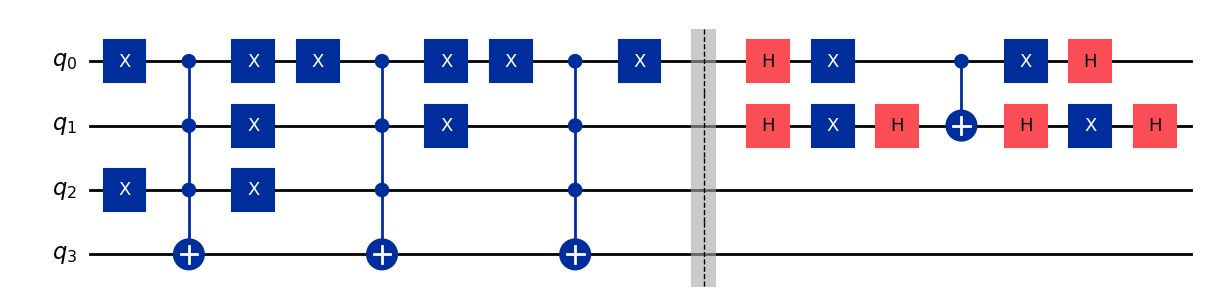

In [48]:
q1 = QuantumRegister(n+1, "q")
wv = QuantumCircuit(q1)

U_f_multi(wv,q1, T)
wv.barrier()
W(wv, wv.qubits[:n])

wv.draw(output='mpl')

In [49]:
def WV(qc, q, marked_elements: Set[int] = T):
    U_f_multi(qc, q, marked_elements)
    W(qc, q)

def controlled_WV(qc, q, control_qubit, power: int = 1, marked_elements: Set[int] = T):
    # Build WV^power as a subcircuit and then control it
    
    sub = QuantumCircuit(n + 1)
    for _ in range(power):
        WV(sub, sub.qubits, marked_elements)
    cgate = sub.to_gate(label=f'WV^{power}').control(1)
    qc.append(cgate, [control_qubit] + list(q))

In [50]:
q = QuantumRegister(n + 1)
ancillas = QuantumRegister(t)
c = ClassicalRegister(n + t + 1)

mock = QuantumCircuit(q, ancillas, c)
controlled_WV(mock, q, ancillas[1], marked_elements=T)
mock.draw()

010
001
011


┌───────┐
q2_0: ┤0      ├
      │       │
q2_1: ┤1      ├
      │  WV^1 │
q2_2: ┤2      ├
      │       │
q2_3: ┤3      ├
      └───┬───┘
q3_0: ────┼────
          │    
q3_1: ────■────
               
q3_2: ─────────
               
c1: 7/═════════

In [51]:
import qiskit
from qiskit import *
import qiskit_ibm_runtime
import qiskit_aer

from qiskit.circuit.library import QFTGate

010
001
011
010
001
011
010
001
011
010
001
011
010
001
011
010
001
011
010
001
011


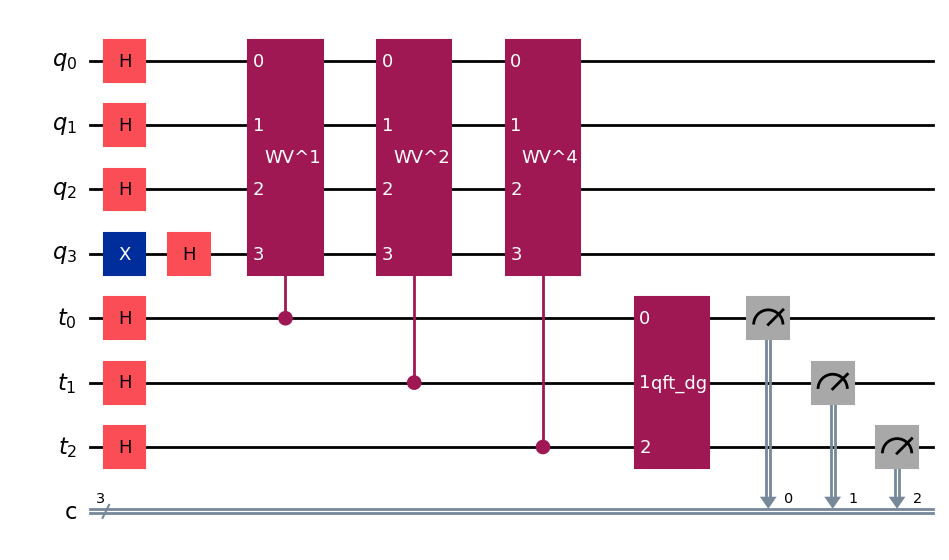

In [52]:
q = QuantumRegister(n + 1, "q")
ancillas = QuantumRegister(t, "t")
c = ClassicalRegister(t, "c")
counting = QuantumCircuit(q, ancillas, c)

# QPE ancillas in uniform superposition
for j in range(t):
    counting.h(ancillas[j])
    

# Initialize target register: data qubits |+>^n, oracle ancilla |->
for i in range(n):
    counting.h(q[i])
counting.x(q[n])
counting.h(q[n])

# Controlled-G^(2^j) for each QPE ancilla j
for j in range(t):
    controlled_WV(counting, q, ancillas[j], power=2**j)

counting.append(QFTGate(t).inverse(), ancillas[:])
counting.measure(ancillas, c)

counting.draw(output='mpl')

In [53]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [54]:
backend = AerSimulator()
sampler = AerSampler()

In [55]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
qpe_isa = pm.run(counting)

In [56]:
job_sim = sampler.run([qpe_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [57]:
# Print the DataBin to see what's inside
list(result_sim.data.keys())

key = list(result_sim.data.keys())[0]
print(key)


c


In [58]:
counts_sim = result_sim.data[key].get_counts()
print(counts_sim)


{'010': 1392, '101': 352, '111': 128, '110': 1548, '011': 352, '000': 73, '100': 142, '001': 109}


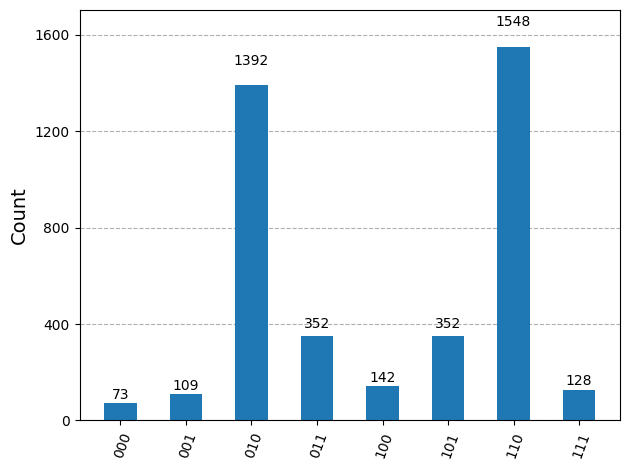

In [59]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

## Post processing 

In [60]:
import math

jm = 9
jp = 23

theta_jm = math.pi - (math.pi*jm)/2**t
theta_jp = (math.pi*jp)/2**t


In [61]:

mm = 2**n * (math.sin(theta_jm - (math.pi/2)))**2
mp = 2**n * (math.sin(theta_jp - (math.pi/2)))**2

mm, mp


(6.82842712474619, 6.828427124746186)

In [62]:
def mtilde(jm, jp):
    theta_jm = math.pi - (math.pi*jm)/2**t
    theta_jp = (math.pi*jp)/2**t
    mm = 2**n * (math.sin(theta_jm - (math.pi/2)))**2
    mp = 2**n * (math.sin(theta_jp - (math.pi/2)))**2

    return mm, mp


## 3. Running on a Quantum Device

In [63]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Initialize the service
service = QiskitRuntimeService(instance="open-instance")

# Filter for real hardware (not simulators) that is currently operational
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend.name}")

Running on: ibm_fez


In [64]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_counting = pm.run(counting)

In [65]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
# Initialize the Sampler for your backend
sampler = Sampler(mode=backend)

In [66]:
# Submit the job
job_exp = sampler.run([isa_counting])
job_exp.job_id()

'd7rpm0st738s73cfrlkg'

In [67]:
job_exp.status()

'QUEUED'

In [68]:
result_exp = job_exp.result()[0]


In [69]:
# Print the DataBin to see what's inside
list(result_exp.data.keys())

['c']

In [70]:

counts_exp = result_exp.data.c.get_counts()
print(counts_exp)

{'110': 471, '001': 516, '010': 467, '101': 559, '111': 555, '100': 556, '000': 428, '011': 544}


In [71]:
run1 = {'01001': 130, '00101': 141, '10101': 94, '10111': 95, '11101': 168, '11111': 144, '01110': 137, '01000': 136, '11010': 132, '00001': 137, '11011': 131, '00110': 119, '00010': 143, '01100': 141, '10011': 101, '10100': 116, '01101': 125, '00011': 137, '01010': 152, '01011': 139, '11000': 123, '11100': 122, '01111': 130, '00000': 122, '00111': 135, '11110': 121, '00100': 168, '10010': 129, '11001': 98, '10000': 113, '10001': 124, '10110': 93}

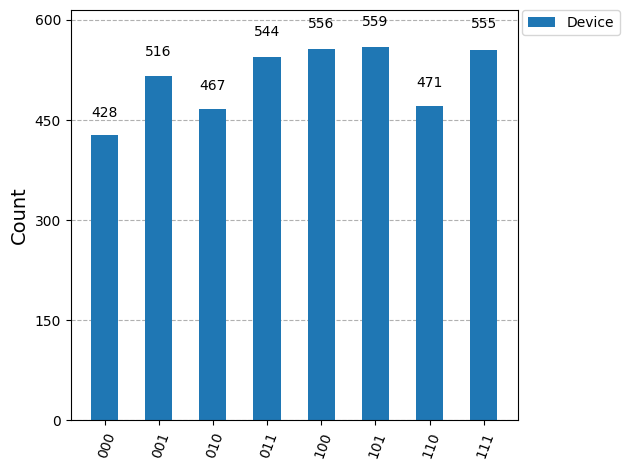

In [72]:
from qiskit.visualization import plot_histogram
plot_histogram([counts_exp], legend=['Device'])

## 2 Qubit Quantum Counting

let $T = {00, 10}$.

In [73]:
n2 = 2
T2 = {0, 2}
t2 = 2

def subU_f_2(qc, q, a: int):
    e = f"{a:02b}"[::-1]
    for i, bit in enumerate(e):
        if bit == '0':
            qc.x(q[i])
    qc.mcx([q[0], q[1]], q[2])
    for i, bit in enumerate(e):
        if bit == '0':
            qc.x(q[i])

def WV_2(qc, q, marked_elements=T2):
    for element in marked_elements:
        subU_f_2(qc, q, element)
    W(qc, q)  # W is general (uses len(q))

def controlled_WV_2(qc, q, control_qubit, power=1, marked_elements=T2):
    sub = QuantumCircuit(n2 + 1)
    for _ in range(power):
        WV_2(sub, sub.qubits, marked_elements)
    cgate = sub.to_gate(label=f'WV2^{power}').control(1)
    qc.append(cgate, [control_qubit] + list(q))

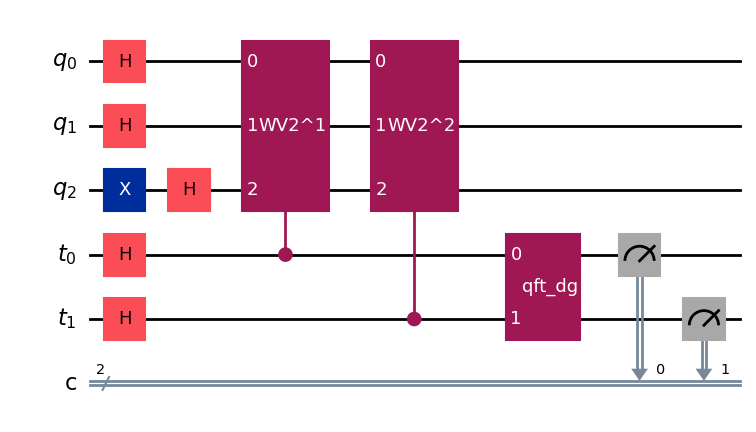

In [74]:
q2 = QuantumRegister(n2 + 1, "q")
anc2 = QuantumRegister(t2, "t")
c2 = ClassicalRegister(t2, "c")
counting2 = QuantumCircuit(q2, anc2, c2)

for j in range(t2):
    counting2.h(anc2[j])

for i in range(n2):
    counting2.h(q2[i])
counting2.x(q2[n2])
counting2.h(q2[n2])

for j in range(t2):
    controlled_WV_2(counting2, q2, anc2[j], power=2**j)

counting2.append(QFTGate(t2).inverse(), anc2[:])
counting2.measure(anc2, c2)

counting2.draw(output='mpl')

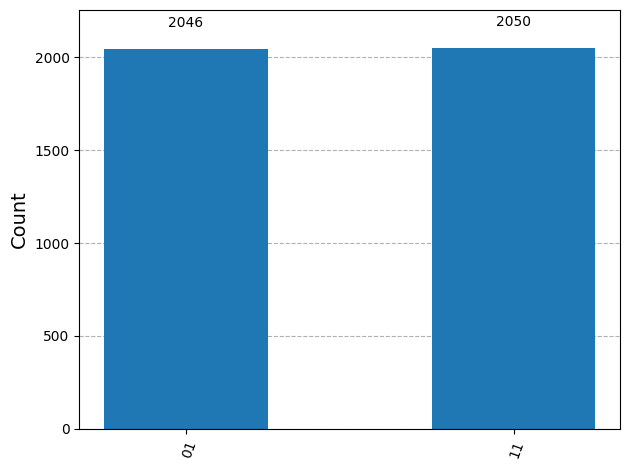

In [75]:
pm2 = generate_preset_pass_manager(optimization_level=1, backend=AerSimulator())
isa2 = pm2.run(counting2)
job2 = AerSampler().run([isa2], shots=4096)
result2 = job2.result()[0]

key2 = list(result2.data.keys())[0]
counts2 = result2.data[key2].get_counts()
plot_histogram(counts2)

In [76]:
import math

jm2, jp2 = 4, 12
mm2 = (2**n2) * (math.sin(math.pi * (jm2 / 2**t2 - 1/2)))**2
mp2= (2**n2) * (math.sin(math.pi * (jp2 / 2**t2 - 1/2)))**2
mm2, mp2

(4.0, 4.0)

In [77]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Initialize the service
service = QiskitRuntimeService(instance="open-instance")

# Filter for real hardware (not simulators) that is currently operational
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend.name}")

Running on: ibm_fez


In [78]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_counting2 = pm.run(counting2)

In [79]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
# Initialize the Sampler for your backend
sampler = Sampler(mode=backend)

In [80]:
# Submit the job
job_exp = sampler.run([isa_counting2])
job_exp.job_id()

'd7rpm6iudops739600ng'

In [81]:
job_exp.status()

'QUEUED'

In [82]:
result_exp = job_exp.result()[0]


In [83]:

counts_exp = result_exp.data.c.get_counts()
print(counts_exp)

{'00': 983, '01': 1018, '10': 1050, '11': 1045}


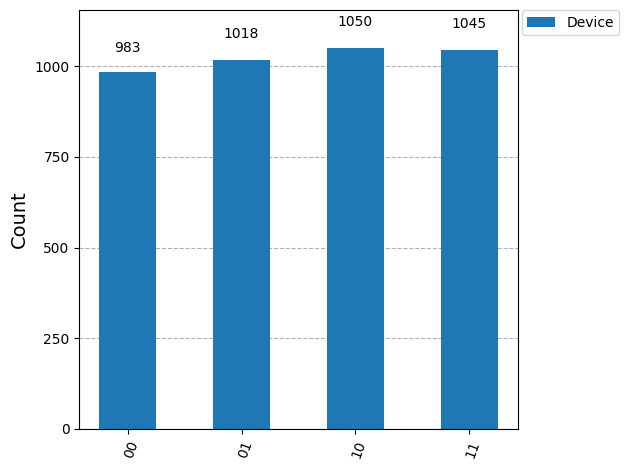

In [84]:
plot_histogram([counts_exp], legend=['Device'])